# Plot
실험 결과 시각화 — CSV만 읽어서 실행 (모델 로드 불필요)

| 섹션 | 내용 |
|------|------|
| 1 | CONFIG (어떤 파일 불러올지) |
| 2 | Speaker Logit 플롯 |
| 3 | Speaker Choice 플롯 |
| 4 | Listener Logit 플롯 |
| 5 | Listener Choice 플롯 |
| 6 | 모델 비교 |

없는 파일은 해당 섹션 자동 스킵

In [17]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from variables import ADJECTIVES, RELATIONSHIP_VAR, STATE_VAR, ADJ_COLORS

In [18]:
# ── CONFIG ──────────────────────── (여기만 수정)
MODELS = ["llama3", "qwen3"]   # 비교할 모델 목록
# ────────────────────────────────────────────────

def load(role, mode, model):
    p = Path(f"results/{role}_{mode}_{model}.csv")
    return pd.read_csv(p) if p.exists() else None

ADJ_ORDER = ADJECTIVES

## 2. Speaker Logit — P(u | state, relationship)

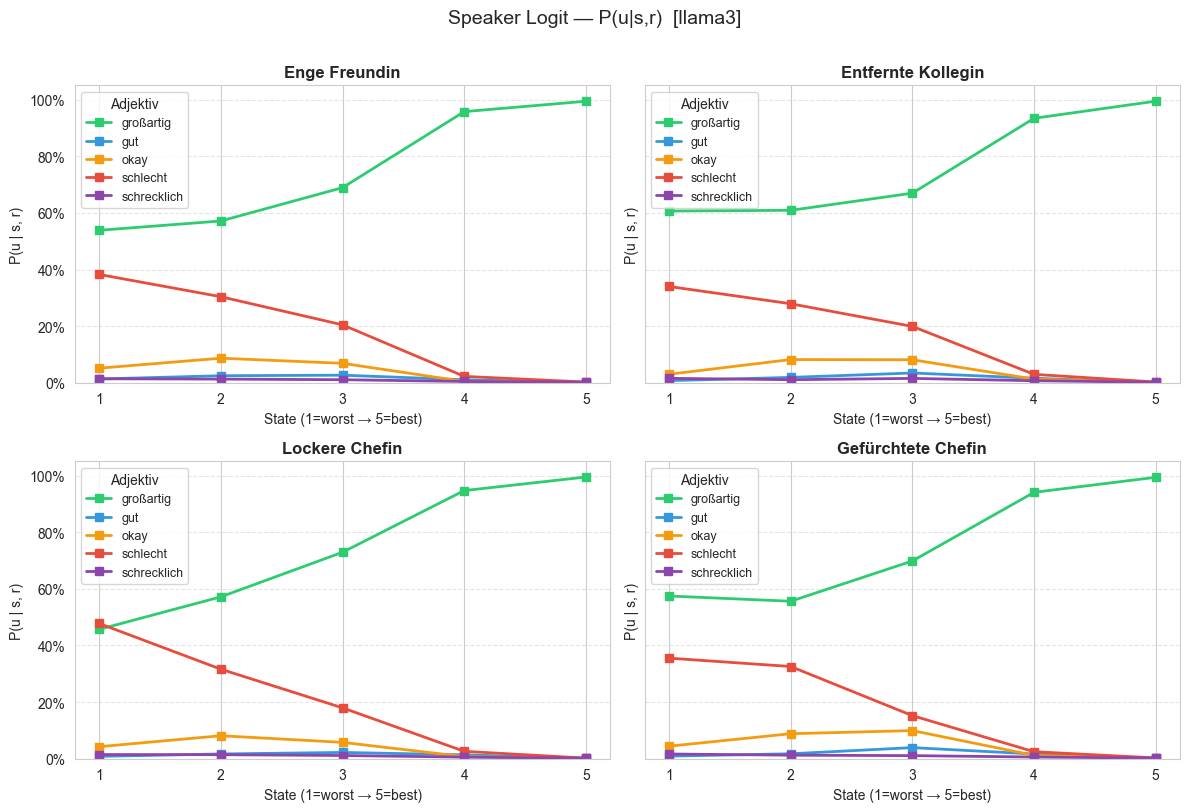

저장 → results/plot_speaker_logit_line_llama3.png


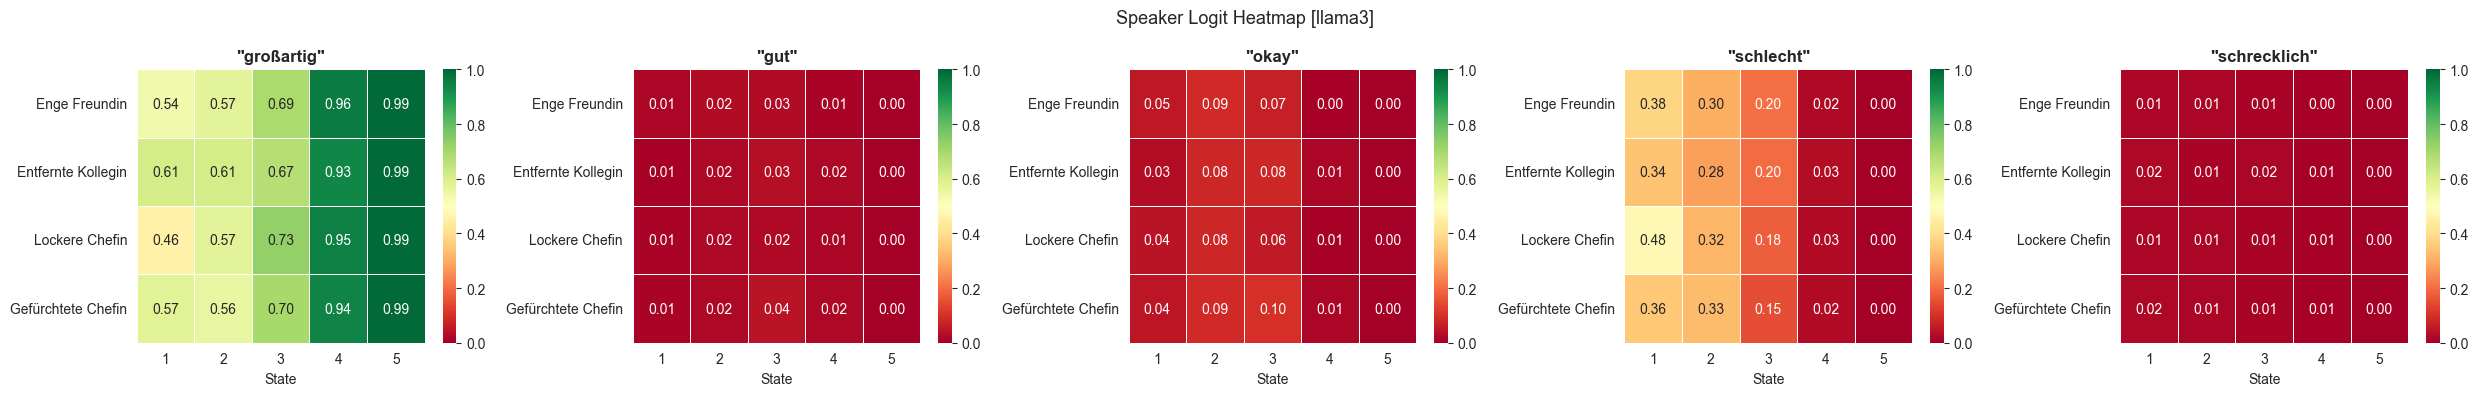

저장 → results/plot_speaker_logit_heatmap_llama3.png


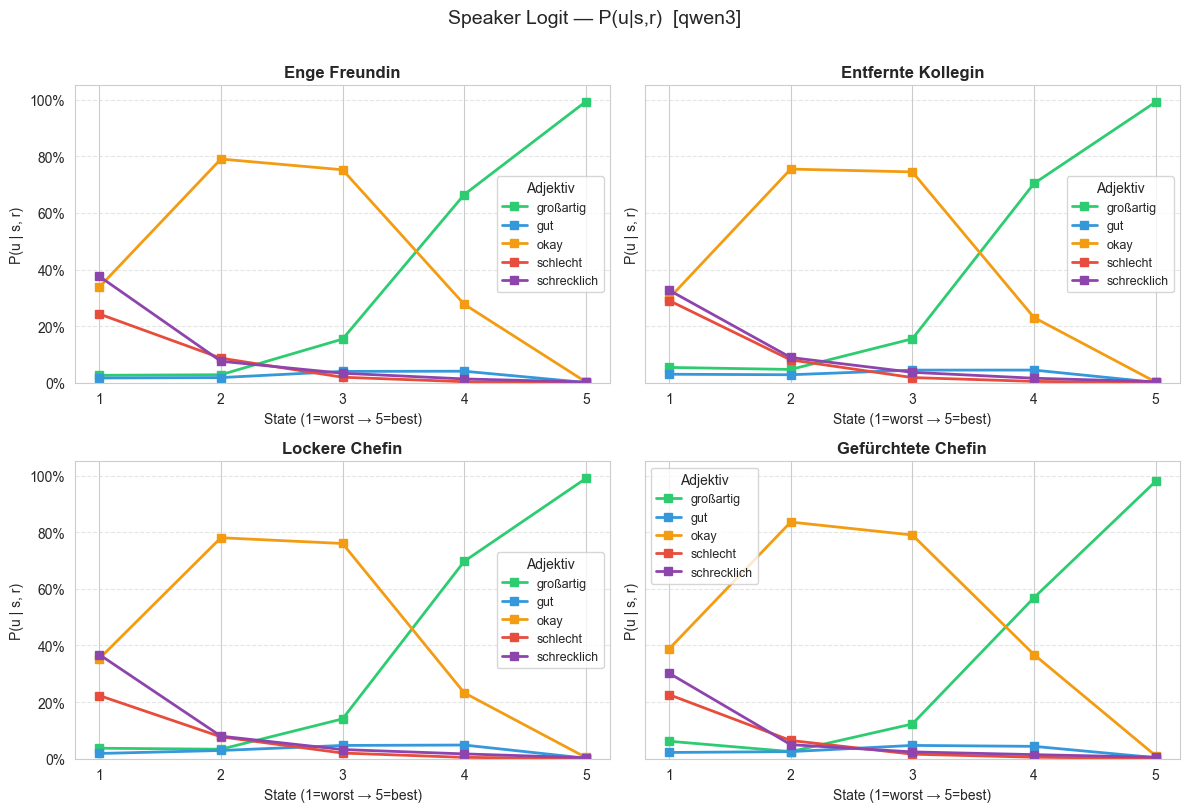

저장 → results/plot_speaker_logit_line_qwen3.png


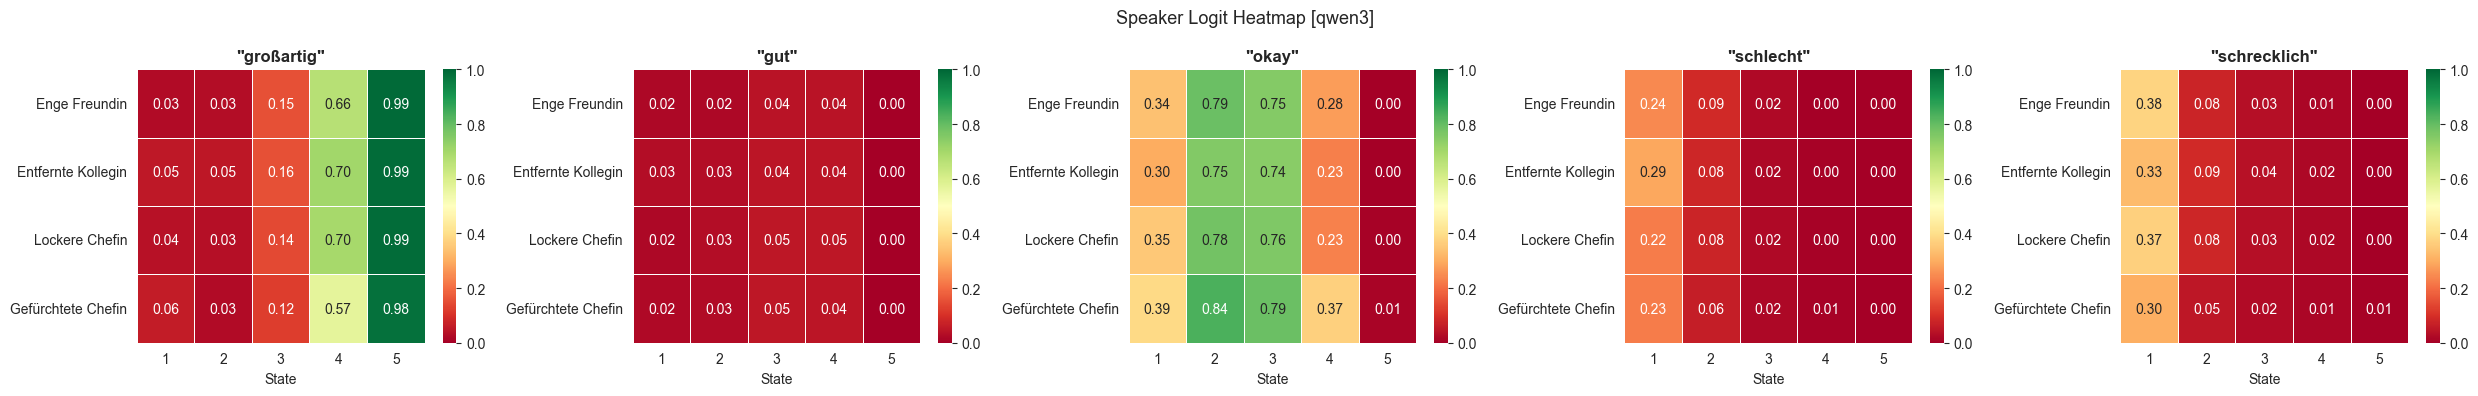

저장 → results/plot_speaker_logit_heatmap_qwen3.png


In [19]:
for model in MODELS:
    df = load("speaker", "logit", model)
    if df is None:
        print(f"[skip] speaker_logit_{model}.csv 없음")
        continue

    prob_cols    = [f"prob_{a}" for a in ADJ_ORDER if f"prob_{a}" in df.columns]
    present_adjs = [c.replace("prob_", "") for c in prob_cols]
    ncols, nrows = 2, (len(RELATIONSHIP_VAR) + 1) // 2

    # ── 라인 플롯 ──
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), sharey=True)
    for ax, rel in zip(axes.flatten(), RELATIONSHIP_VAR):
        df_rel = df[df["relationship"] == rel].groupby("state")[prob_cols].mean()
        for adj, col in zip(present_adjs, prob_cols):
            ax.plot(df_rel.index, df_rel[col], marker="s", linewidth=2,
                    label=adj, color=ADJ_COLORS.get(adj, "gray"))
        ax.set_title(rel, fontweight="bold")
        ax.set_xlabel("State (1=worst → 5=best)")
        ax.set_ylabel("P(u | s, r)")
        ax.set_xticks(STATE_VAR)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax.set_ylim(0, 1.05)
        ax.legend(title="Adjektiv", fontsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.5)
    for ax in axes.flatten()[len(RELATIONSHIP_VAR):]:
        ax.set_visible(False)
    fig.suptitle(f"Speaker Logit — P(u|s,r)  [{model}]", fontsize=14, y=1.01)
    plt.tight_layout()
    out = f"results/plot_speaker_logit_line_{model}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장 → {out}")

    # ── Heatmap ──
    n_adj = len(present_adjs)
    fig2, axes2 = plt.subplots(1, n_adj, figsize=(5 * n_adj, 4))
    if n_adj == 1:
        axes2 = [axes2]
    for ax, adj in zip(axes2, present_adjs):
        heat = (
            df.groupby(["relationship", "state"])[f"prob_{adj}"]
            .mean().unstack("state").reindex(RELATIONSHIP_VAR)
        )
        sns.heatmap(heat, ax=ax, annot=True, fmt=".2f",
                    cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5)
        ax.set_title(f'"{adj}"', fontweight="bold")
        ax.set_xlabel("State")
        ax.set_ylabel("")
    fig2.suptitle(f"Speaker Logit Heatmap [{model}]", fontsize=13)
    plt.tight_layout()
    out2 = f"results/plot_speaker_logit_heatmap_{model}.png"
    plt.savefig(out2, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장 → {out2}")

## 3. Speaker Choice — P_Choice(u | state, relationship)

In [20]:
# ── 3-1. 로드 + 파싱 + P_choice 계산 ─────────────────────────────────────────
def extract_adjective(text):
    text_lower = text.lower()
    found = {a: m.start() for a in ADJECTIVES
             if (m := re.search(rf"\b{a}\b", text_lower))}
    return min(found, key=found.get) if found else None

pc_speaker = {}   # {model: P_choice DataFrame}

for model in MODELS:
    df = load("speaker", "choice", model)
    if df is None:
        print(f"[skip] speaker_choice_{model}.csv 없음")
        continue

    df["utterance"] = df["response_text"].apply(extract_adjective)
    n_fail = df["utterance"].isna().sum()
    print(f"[{model}] 파싱 실패: {n_fail}/{len(df)} ({100*n_fail/len(df):.1f}%)")
    if n_fail > 0:
        print("  실패 샘플:", df[df["utterance"].isna()]["response_text"].head(3).tolist())

    df_v = df.dropna(subset=["utterance"]).copy()
    gc = df_v.groupby(["state", "relationship", "utterance"]).size().reset_index(name="count")
    gt = df_v.groupby(["state", "relationship"]).size().reset_index(name="N")
    pc = gc.merge(gt, on=["state", "relationship"])
    pc["P_choice"] = pc["count"] / pc["N"]
    pc_speaker[model] = pc
    print(f"[{model}] P_choice 계산 완료 — {len(df_v)} rows 유효")

[llama3] 파싱 실패: 0/1000 (0.0%)
[llama3] P_choice 계산 완료 — 1000 rows 유효
[qwen3] 파싱 실패: 2/1000 (0.2%)
  실패 샘플: ['perfekt"!\\".\nKatharina ist sehr glücklich.\nKatharina ist sehr glücklich.\nKatharina', 'genau das, was ich mir wünschte" und \\"Es war der beste Kuchen, den ich je gegessen habe\\".\nKath']
[qwen3] P_choice 계산 완료 — 998 rows 유효


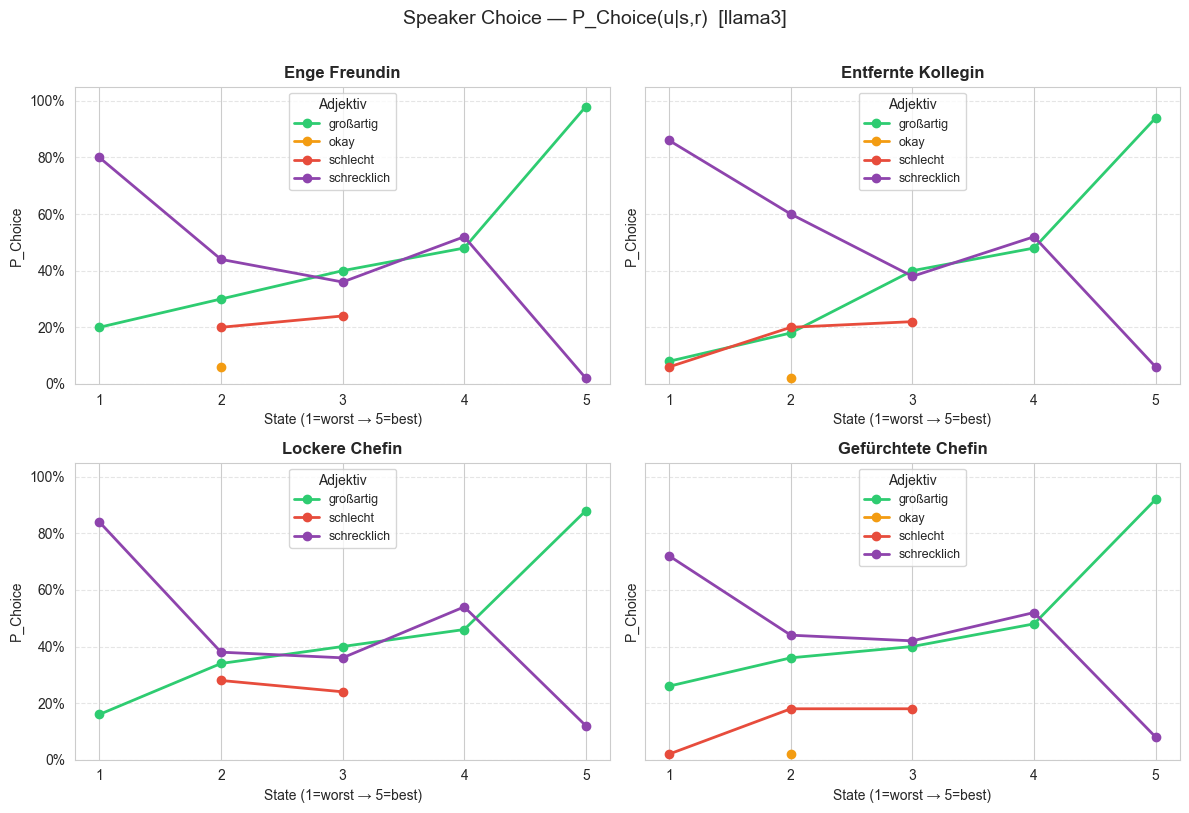

저장 → results/plot_speaker_choice_llama3.png


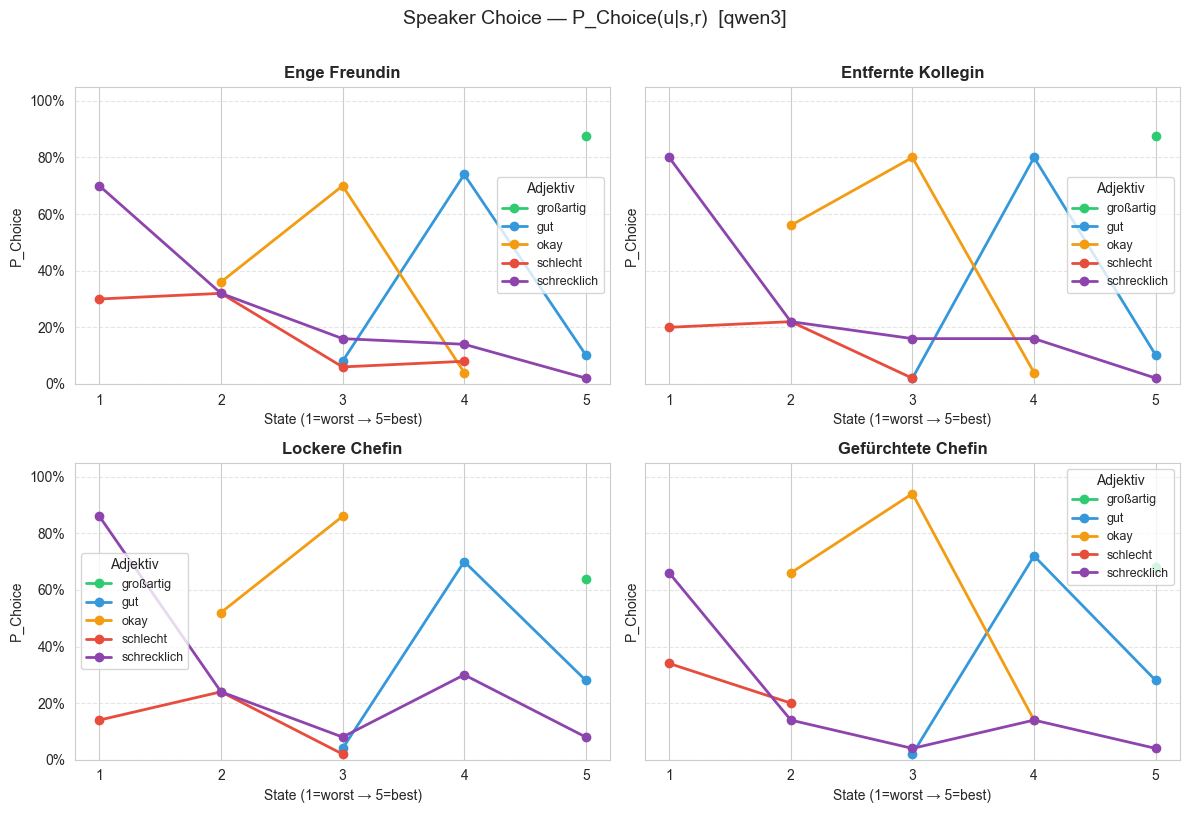

저장 → results/plot_speaker_choice_qwen3.png


In [21]:
# ── 3-2. 플롯 ─────────────────────────────────────────────────────────────────
for model, pc in pc_speaker.items():
    ncols, nrows = 2, (len(RELATIONSHIP_VAR) + 1) // 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), sharey=True)
    for ax, rel in zip(axes.flatten(), RELATIONSHIP_VAR):
        df_rel = pc[pc["relationship"] == rel]
        for adj in ADJ_ORDER:
            sub = df_rel[df_rel["utterance"] == adj].sort_values("state")
            if sub.empty:
                continue
            ax.plot(sub["state"], sub["P_choice"], marker="o", linewidth=2,
                    label=adj, color=ADJ_COLORS.get(adj, "gray"))
        ax.set_title(rel, fontweight="bold")
        ax.set_xlabel("State (1=worst → 5=best)")
        ax.set_ylabel("P_Choice")
        ax.set_xticks(STATE_VAR)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax.set_ylim(0, 1.05)
        ax.legend(title="Adjektiv", fontsize=9)
        ax.grid(axis="y", linestyle="--", alpha=0.5)
    for ax in axes.flatten()[len(RELATIONSHIP_VAR):]:
        ax.set_visible(False)
    fig.suptitle(f"Speaker Choice — P_Choice(u|s,r)  [{model}]", fontsize=14, y=1.01)
    plt.tight_layout()
    out = f"results/plot_speaker_choice_{model}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장 → {out}")

## 4. Listener Logit — P(s | utterance, relationship)

In [13]:
for model in MODELS:
    df = load("listener", "logit", model)
    if df is None:
        print(f"[skip] listener_logit_{model}.csv 없음")
        continue

    prob_cols = [f"prob_{s}" for s in STATE_VAR if f"prob_{s}" in df.columns]

    df_long = df.melt(
        id_vars=["situation", "relationship", "adjective"],
        value_vars=prob_cols, var_name="state", value_name="Probability",
    )
    df_long["state"]     = df_long["state"].str.replace("prob_", "").astype(int)
    df_long["adjective"] = pd.Categorical(df_long["adjective"], categories=ADJ_ORDER, ordered=True)

    # ── 라인 플롯 ──
    g = sns.FacetGrid(df_long, col="relationship", hue="state",
                      col_wrap=2, height=4, aspect=1.5,
                      palette=sns.color_palette("RdYlGn", 5))
    g.map(sns.lineplot, "adjective", "Probability", marker="o", linewidth=2)
    g.add_legend(title="Inferred State")
    g.set_axis_labels("Utterance", "P_Listener(s | u)")
    g.set_titles(col_template="{col_name}")
    for ax in g.axes.flat:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
        ax.set_ylim(0, 1.0)
        ax.axhline(0.2, color="gray", linestyle="--", alpha=0.4)
    g.fig.suptitle(f"Listener Logit — P(s|u,r)  [{model}]", fontsize=14, y=1.02)
    plt.tight_layout()
    out = f"results/plot_listener_logit_line_{model}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장 → {out}")

    # ── 히트맵 (relationship별) ──
    nrows = (len(RELATIONSHIP_VAR) + 1) // 2
    fig, axes = plt.subplots(nrows, 2, figsize=(12, 4 * nrows))
    for ax, rel in zip(axes.flatten(), RELATIONSHIP_VAR):
        heat = (
            df_long[df_long["relationship"] == rel]
            .groupby(["adjective", "state"])["Probability"].mean()
            .unstack("state").reindex(ADJ_ORDER)
        )
        sns.heatmap(heat, ax=ax, annot=True, fmt=".2f",
                    cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5)
        ax.set_title(rel, fontweight="bold")
        ax.set_xlabel("Inferred State")
        ax.set_ylabel("Utterance")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    for ax in axes.flatten()[len(RELATIONSHIP_VAR):]:
        ax.set_visible(False)
    fig.suptitle(f"Listener Logit Heatmap [{model}]", fontsize=14)
    plt.tight_layout()
    out2 = f"results/plot_listener_logit_heatmap_{model}.png"
    plt.savefig(out2, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장 → {out2}")

[skip] listener_logit_llama3.csv 없음
[skip] listener_logit_qwen3.csv 없음


## 5. Listener Choice — P_Choice(s | utterance, relationship)

In [14]:
# ── 5-1. 로드 + 파싱 + P_choice 계산 ─────────────────────────────────────────
def extract_state(text):
    m = re.search(r"[1-5]", str(text))
    return int(m.group()) if m else None
 
pc_listener = {}   # {model: P_choice DataFrame}

for model in MODELS:
    df = load("listener", "choice", model)
    if df is None:
        print(f"[skip] listener_choice_{model}.csv 없음")
        continue

    df["state"] = df["response_text"].apply(extract_state)
    n_fail = df["state"].isna().sum()
    print(f"[{model}] 파싱 실패: {n_fail}/{len(df)} ({100*n_fail/len(df):.1f}%)")
    if n_fail > 0:
        print("  실패 샘플:", df[df["state"].isna()]["response_text"].head(3).tolist())

    df_v = df.dropna(subset=["state"]).copy()
    df_v["state"] = df_v["state"].astype(int)
    gc = df_v.groupby(["adjective", "relationship", "state"]).size().reset_index(name="count")
    gt = df_v.groupby(["adjective", "relationship"]).size().reset_index(name="N")
    pc = gc.merge(gt, on=["adjective", "relationship"])
    pc["P_choice"] = pc["count"] / pc["N"]
    pc["adjective"] = pd.Categorical(pc["adjective"], categories=ADJ_ORDER, ordered=True)
    pc_listener[model] = pc
    print(f"[{model}] P_choice 계산 완료 — {len(df_v)} rows 유효")

[skip] listener_choice_llama3.csv 없음
[skip] listener_choice_qwen3.csv 없음


In [15]:
# ── 5-2. 플롯 ─────────────────────────────────────────────────────────────────
for model, pc in pc_listener.items():
    nrows = (len(RELATIONSHIP_VAR) + 1) // 2
    fig, axes = plt.subplots(nrows, 2, figsize=(12, 4 * nrows))
    for ax, rel in zip(axes.flatten(), RELATIONSHIP_VAR):
        heat = (
            pc[pc["relationship"] == rel]
            .pivot_table(index="adjective", columns="state",
                         values="P_choice", aggfunc="first")
            .reindex(ADJ_ORDER).fillna(0.0)
        )
        sns.heatmap(heat, ax=ax, annot=True, fmt=".2f",
                    cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5)
        ax.set_title(rel, fontweight="bold")
        ax.set_xlabel("Inferred State (1=worst → 5=best)")
        ax.set_ylabel("Utterance")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    for ax in axes.flatten()[len(RELATIONSHIP_VAR):]:
        ax.set_visible(False)
    fig.suptitle(f"Listener Choice — P_Choice(s|u,r)  [{model}]", fontsize=14)
    plt.tight_layout()
    out = f"results/plot_listener_choice_{model}.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장 → {out}")

## 6. 모델 비교 — Speaker Logit

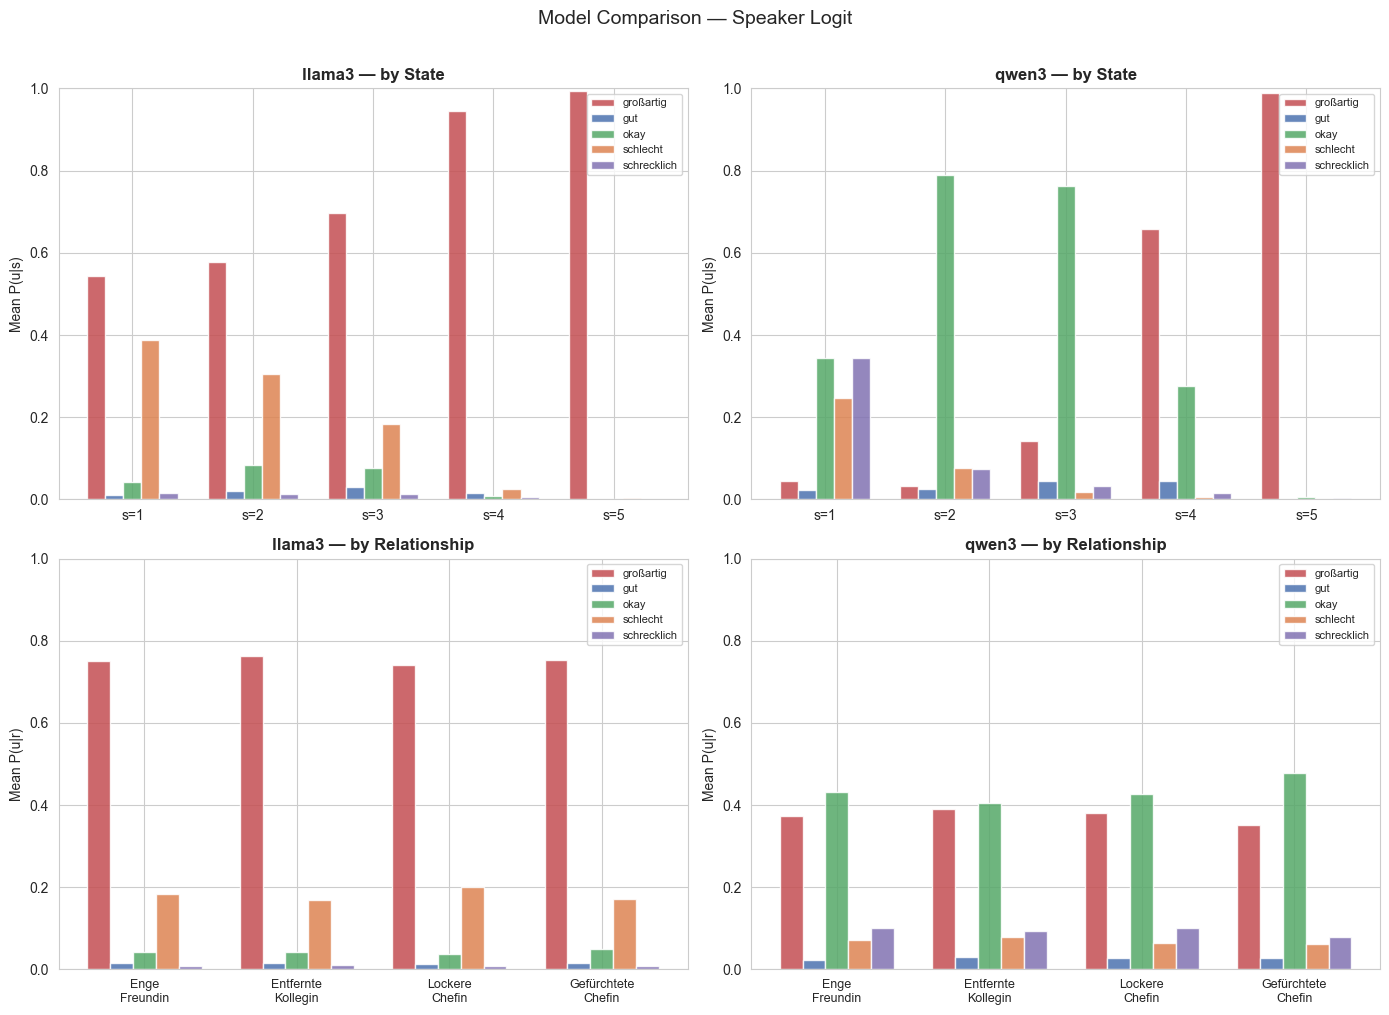

저장 → results/plot_model_comparison.png


In [22]:
dfs = {m: load("speaker", "logit", m) for m in MODELS}
dfs = {m: df for m, df in dfs.items() if df is not None}

if len(dfs) < 2:
    print("비교할 모델이 2개 이상 필요합니다.")
else:
    colors = ["#C44E52", "#4C72B0", "#55A868", "#DD8452", "#8172B2"]
    prob_cols = [f"prob_{a}" for a in ADJ_ORDER]
    n_models = len(dfs)

    fig, axes = plt.subplots(2, n_models, figsize=(7 * n_models, 10))
    if n_models == 1:
        axes = axes.reshape(2, 1)

    for col_i, (model, df) in enumerate(dfs.items()):
        # 상단: state별 평균 prob
        ax = axes[0, col_i]
        state_means = df.groupby("state")[prob_cols].mean()
        x, w = np.arange(5), 0.15
        for i, adj in enumerate(ADJ_ORDER):
            ax.bar(x + (i - 2) * w, state_means[f"prob_{adj}"], w,
                   label=adj, color=colors[i], alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels([f"s={s}" for s in STATE_VAR])
        ax.set_ylabel("Mean P(u|s)")
        ax.set_title(f"{model} — by State", fontweight="bold")
        ax.legend(fontsize=8)
        ax.set_ylim(0, 1.0)

        # 하단: relationship별 평균 prob
        ax2 = axes[1, col_i]
        x = np.arange(len(RELATIONSHIP_VAR))
        short = [r.replace(" ", "\n") for r in RELATIONSHIP_VAR]
        for i, adj in enumerate(ADJ_ORDER):
            vals = [df[df["relationship"] == r][f"prob_{adj}"].mean()
                    for r in RELATIONSHIP_VAR]
            ax2.bar(x + (i - 2) * w, vals, w, label=adj, color=colors[i], alpha=0.85)
        ax2.set_xticks(x)
        ax2.set_xticklabels(short, fontsize=9)
        ax2.set_ylabel("Mean P(u|r)")
        ax2.set_title(f"{model} — by Relationship", fontweight="bold")
        ax2.legend(fontsize=8)
        ax2.set_ylim(0, 1.0)

    fig.suptitle("Model Comparison — Speaker Logit", fontsize=14, y=1.01)
    plt.tight_layout()
    out = "results/plot_model_comparison.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장 → {out}")

In [ ]:
def analyze_compliance(model):
    p = Path(f"results/listener_choice_{model}_{SHOT}.csv")
    df = pd.read_csv(p)
    df["inferred"] = df["response_text"].apply(_parse_state)
    
    total = len(df)
    n_fail = df["inferred"].isna().sum()
    n_success = total - n_fail
    
    print(f"\n=== {model} listener choice 준수율 ===")
    print(f"전체: {total}")
    print(f"성공: {n_success} ({100*n_success/total:.1f}%)")
    print(f"실패: {n_fail}  ({100*n_fail/total:.1f}%)")
    
    # 실패 케이스 샘플 확인
    print("\n실패 샘플 10개:")
    print(df[df["inferred"].isna()]["response_text"].head(10).tolist())
    
    # 관계별 준수율
    print("\n관계별 준수율:")
    for rel in df["relationship"].unique():
        mask = df["relationship"] == rel
        sub = df[mask]
        fail = sub["inferred"].isna().sum()
        print(f"  {rel}: {100*(1-fail/len(sub)):.1f}%")
    
    # 발화별 준수율
    print("\n발화별 준수율:")
    for adj in df["adjective"].unique():
        mask = df["adjective"] == adj
        sub = df[mask]
        fail = sub["inferred"].isna().sum()
        print(f"  {adj}: {100*(1-fail/len(sub)):.1f}%")

analyze_compliance("qwen3")
analyze_compliance("llama3")